In [1]:
# on va ici faire tout les import necessaire pour le bon fonctionnement du programme

from trafic import *
import matplotlib.pyplot as plt

%load_ext autoreload
%autoreload 2



In [2]:
#on met les fonction de stats.ipynb ici pour avoir les meme fonction et eviter les confmlit de logique

def position_voiture(route, voiture):
    
    for i in range(route.shape[0]):
        if route[i] == voiture:
            return i
    return -1

def calculer_vmoy(vitesses):
    return np.mean(list(vitesses.values()))


def distance_devant(route, i):
    n = route.shape[0]
    d = 1
    while d < n:
        if route[(i+d)%n] > 0:
            break
        d += 1
    return d


def calculer_embouteillage(route):
    n = route.shape[0]
    somme = 0
    i = 0
    while i < n:
        if route[i] > 0:
            d = distance_devant(route, i)
            somme += 1/d**2
            i += d
        else:
            i += 1
    return 1/n * somme

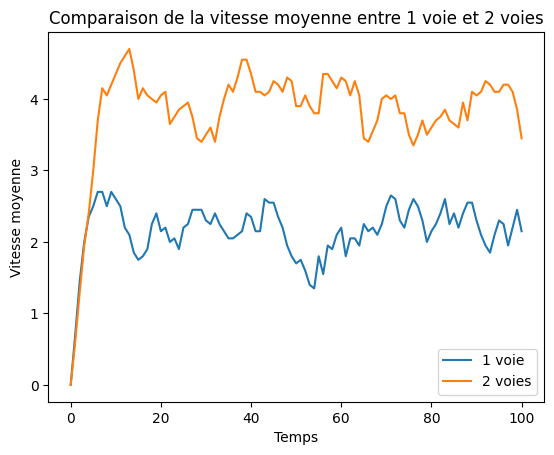

In [3]:
# on veut creer un modele a 2 voie avec 100 case et 20 voiture, une vmax = 5 et p = 0,3 
# ainsi qu'un modele a 1 voie avec les meme parametre afin de comparer les deux modele
taille = 100
nbr_voie = 2
nbr_voiture = 20

vmax = {}
for i in range(1, nbr_voiture+1):
    vmax[i] = 5

modele1 = ModeleSimple(5, 0.3)
modele2 = ModelePlusieursVoies(vmax,0.3,0,0)
route1, vitesse1 = config_equidistance(taille, nbr_voiture)
route2, vitesse2 = config_equidistance_plusieurs_voies(taille, nbr_voie, nbr_voiture)

traj_route1, traj_vitesse1 = modele1.trajectoire(route1, vitesse1, 100)
traj_route2, traj_vitesse2 = modele2.trajectoire(route2, vitesse2, 100)


# maintenant qu'on a creer le modele je vais calculer la moyenne sur chaque voie *
vmoy2 = [calculer_vmoy(v) for v in traj_vitesse2]
vmoy1 = [calculer_vmoy(v) for v in traj_vitesse1]

plt.plot(vmoy1, label="1 voie")
plt.plot(vmoy2, label="2 voies")
plt.legend()
plt.xlabel("Temps")
plt.ylabel("Vitesse moyenne")
plt.title("Comparaison de la vitesse moyenne entre 1 voie et 2 voies")
plt.show()


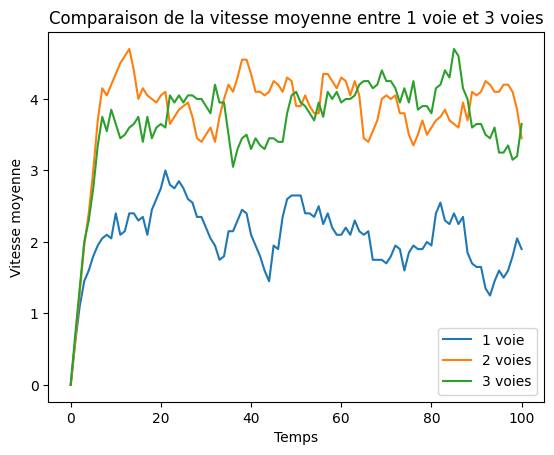

In [4]:
# on veut creer un modele a 2 voie avec 100 case et 20 voiture, une vmax = 5 et p = 0,3 
# ainsi qu'un modele a 1 voie avec les meme parametre afin de comparer les deux modele
taille = 100
nbr_voie = 3
nbr_voiture = 20

vmax = {}
for i in range(1, nbr_voiture+1):
    vmax[i] = 5

modele1 = ModeleSimple(5, 0.3)
modele3 = ModelePlusieursVoies(vmax,0.3,0,0)
route1, vitesse1 = config_equidistance(taille, nbr_voiture)
route3, vitesse3 = config_equidistance_plusieurs_voies(taille, nbr_voie, nbr_voiture)

traj_route1, traj_vitesse1 = modele1.trajectoire(route1, vitesse1, 100)
traj_route3, traj_vitesse3 = modele3.trajectoire(route3, vitesse3, 100)

# maintenant qu'on a creer le modele je vais calculer la moyenne sur chaque voie *
vmoy3 = [calculer_vmoy(v) for v in traj_vitesse3]
vmoy1 = [calculer_vmoy(v) for v in traj_vitesse1]

plt.plot(vmoy1, label="1 voie")
plt.plot(vmoy2, label="2 voies")
plt.plot(vmoy3, label="3 voies")
plt.legend()
plt.xlabel("Temps")
plt.ylabel("Vitesse moyenne")
plt.title("Comparaison de la vitesse moyenne entre 1 voie et 3 voies")
plt.show()


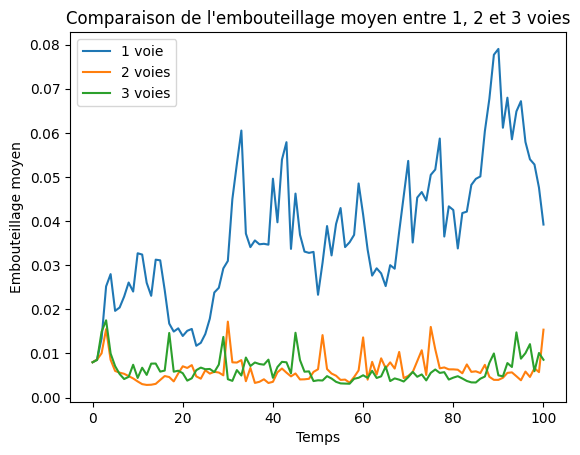

In [5]:
#je vais creer une fonction qui calcule les embouteillages moyens sur une simulation
def calculer_embouteillage(route):
    n = route.shape[0]
    somme = 0
    i = 0
    while i < n:
        if route[i] > 0:
            d = distance_devant(route, i)
            somme += 1/d**2
            i += d
        else:
            i += 1
    return 1/n * somme

def calculer_embouteillage_plusieur_voies(route):
    somme = 0
    for i in range(route.shape[0]):
        somme += calculer_embouteillage(route[i])
    return somme
    
emb1 = [calculer_embouteillage(route) for route in traj_route1]
emb2 = [calculer_embouteillage_plusieur_voies(route) for route in traj_route2]
emb3 = [calculer_embouteillage_plusieur_voies(route) for route in traj_route3]

plt.plot(emb1)
plt.plot(emb2)
plt.plot(emb3)
plt.legend(["1 voie", "2 voies", "3 voies"])
plt.xlabel("Temps")
plt.ylabel("Embouteillage moyen")
plt.title("Comparaison de l'embouteillage moyen entre 1, 2 et 3 voies")
plt.show()



1 voie hétérogène — vitesse moyenne finale : 1.973
2 voies hétérogène (toutes voitures sur voie 0) — vitesse moyenne finale : 3.531


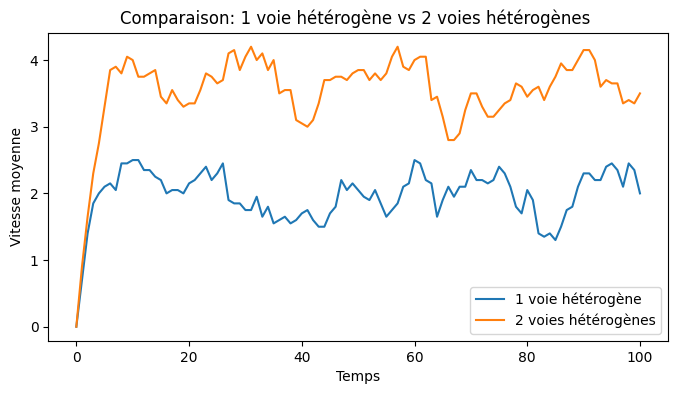

In [10]:
import random
random.seed(0)

taille = 100
nbr_voie = 2
nbr_voiture = 20
p_ex = 0.3
T_sim = 100

vmaxhetero = {i: random.randint(4, 6) for i in range(1, nbr_voiture + 1)}

#  1 voie hétérogène (modèle 1D avec vmax différents)
route1, vitesse1 = config_equidistance(taille, nbr_voiture)

modele1vhetero = ModeleDiffVmax(vmaxhetero, p_ex)
traj_route1, traj_vitesse1 = modele1vhetero.trajectoire(route1.copy(), vitesse1.copy(), T_sim)
vmoy1hetero = [calculer_vmoy(v) for v in traj_vitesse1]


#  2 voies hétérogène 

route2, vitesse2 = config_equidistance_plusieurs_voies(taille, nbr_voie, nbr_voiture)


modele2vhetero = ModelePlusieursVoies(vmaxhetero, p_ex, 0.0, 0)
traj_route2, traj_vitesse2 = modele2vhetero.trajectoire(route2.copy(), vitesse2.copy(), T_sim)
vmoy2hetero = [calculer_vmoy(v) for v in traj_vitesse2]

# Comparaisons et affichage
print(f"1 voie hétérogène — vitesse moyenne finale : {np.mean(vmoy1hetero):.3f}")
print(f"2 voies hétérogène (toutes voitures sur voie 0) — vitesse moyenne finale : {np.mean(vmoy2hetero):.3f}")

plt.figure(figsize=(8, 4))
plt.plot(vmoy1hetero, label='1 voie hétérogène')
plt.plot(vmoy2hetero, label='2 voies hétérogènes')
plt.xlabel('Temps')
plt.ylabel('Vitesse moyenne')
plt.legend()
plt.title('Comparaison: 1 voie hétérogène vs 2 voies hétérogènes ')
plt.show()




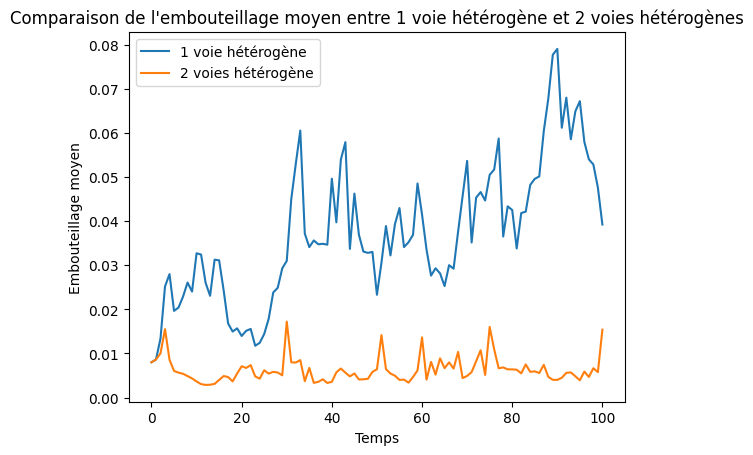

In [8]:
#comparaison des embouteillages moyens entre les deux modeles
emb1hetero = [calculer_embouteillage(route) for route in traj_route1]
emb2hetero = [calculer_embouteillage_plusieur_voies(route) for route in traj_route2]

plt.plot(emb1hetero, label='1 voie hétérogène')
plt.plot(emb2hetero, label='2 voies hétérogène')
plt.xlabel('Temps')
plt.ylabel("Embouteillage moyen")
plt.legend()
plt.title('Comparaison de l\'embouteillage moyen entre 1 voie hétérogène et 2 voies hétérogènes')
plt.show()






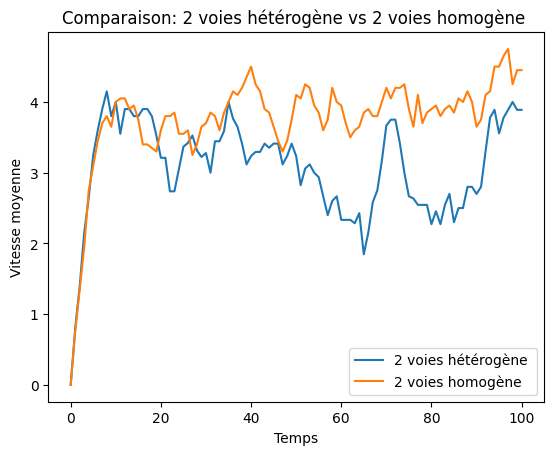

2 voies hétérogène — vitesse moyenne finale : 3.082
2 voies homogène — vitesse moyenne finale : 3.763


In [ ]:
# je compare 2 voie vitesse hetero et 2 voie vitesse homogene 
plt.plot(vmoy2hetero, label='2 voies hétérogène ')
plt.plot(vmoy2, label='2 voies homogène')
plt.xlabel('Temps')
plt.ylabel('Vitesse moyenne')
plt.title('Comparaison: 2 voies hétérogène vs 2 voies homogène ')
plt.legend()
plt.show()

#je compare leur vitesse moyenne finale

print(f"2 voies hétérogène — vitesse moyenne finale : {np.mean(vmoy2hetero):.3f}")
print(f"2 voies homogène — vitesse moyenne finale : {np.mean(vmoy2):.3f}")

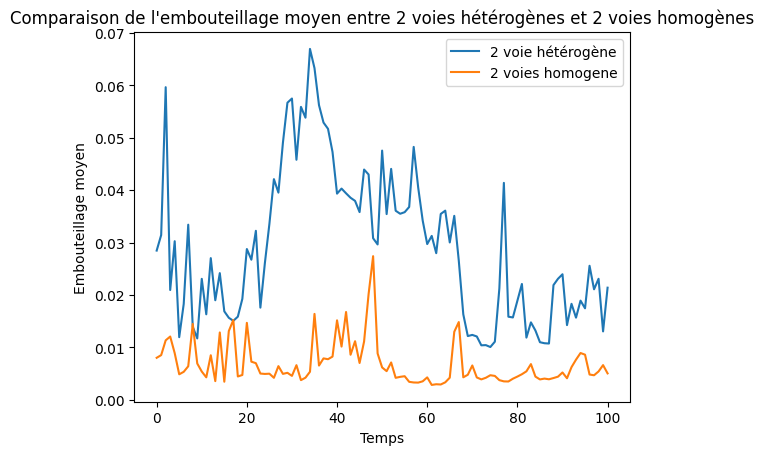

2 voies hétérogène — embouteillage moyen final : 0.021
2 voies homogène — embouteillage moyen final : 0.005


In [ ]:
#on essaye maintenant de comparer  la difference d'embouteillage entre les deux 


plt.plot(emb2hetero, label='2 voie hétérogène')
plt.plot(emb2, label='2 voies homogene')
plt.xlabel('Temps')
plt.ylabel("Embouteillage moyen")
plt.legend()
plt.title('Comparaison de l\'embouteillage moyen entre 2 voies hétérogènes et 2 voies homogènes')
plt.show()
#on compare la valeur finale des embouteillages moyens
print(f"2 voies hétérogène — embouteillage moyen final : {emb2hetero[-1]:.3f}")
print(f"2 voies homogène — embouteillage moyen final : {emb2[-1]:.3f}")

Text(0.5, 1.0, 'Comparaison: 2 voies hétérogènes vs 2 voies homogènes avec plus de voitures (50)')

Text(0.5, 1.0, 'Comparaison: 2 voies hétérogènes vs 2 voies homogènes avec plus de voitures (50)')

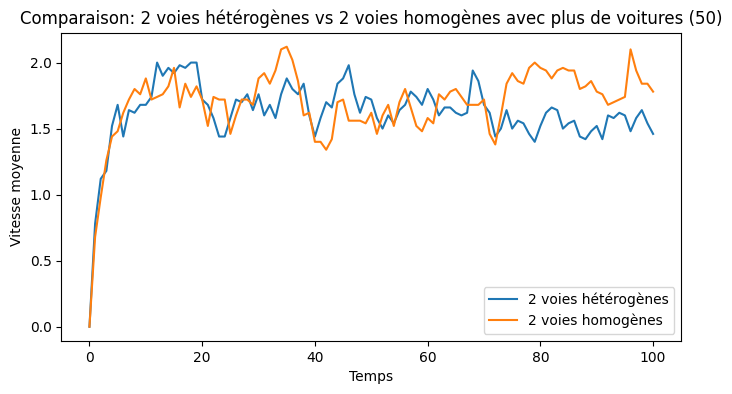

In [ ]:
#maintenant on compare 2 voie homogene avec 2 voie heterogene mais avec plus de voiture
import random
random.seed(0)
taille = 100
nbr_voie = 2
nbr_voiture = 50
p_ex = 0.3
T_sim = 100

vmaxhetero = {i: random.randint(4, 6) for i in range(1, nbr_voiture + 1)}
#  2 voie hétérogène
route2, vitesse2 = config_equidistance_plusieurs_voies(taille, nbr_voie, nbr_voiture)
modele2vhetero = ModelePlusieursVoies(vmaxhetero, p_ex, 0.0, 0)
traj_route2, traj_vitesse2 = modele2vhetero.trajectoire(route2.copy(), vitesse2.copy(), T_sim)
vmoy2hetero = [calculer_vmoy(v) for v in traj_vitesse2]
#  2 voie homogène
route2homo, vitesse2homo = config_equidistance_plusieurs_voies(taille, nbr_voie, nbr_voiture)
modele2vhomo = ModelePlusieursVoies({i: 5 for i in range(1, nbr_voiture + 1)}, p_ex, 0.0, 0)
traj_route2homo, traj_vitesse2homo = modele2vhomo.trajectoire(route2homo.copy(), vitesse2homo.copy(), T_sim)
vmoy2homo = [calculer_vmoy(v) for v in traj_vitesse2homo]
# Comparaisons et affichage
plt.figure(figsize=(8, 4))
plt.plot(vmoy2hetero, label='2 voies hétérogènes')
plt.plot(vmoy2homo, label='2 voies homogènes')
plt.xlabel('Temps')
plt.ylabel('Vitesse moyenne')
plt.legend()
plt.title('Comparaison: 2 voies hétérogènes vs 2 voies homogènes avec plus de voitures (50)')




Text(0.5, 1.0, 'Comparaison: 2 voies hétérogènes vs 2 voies homogènes avec des accidents')

Text(0.5, 1.0, 'Comparaison: 2 voies hétérogènes vs 2 voies homogènes avec des accidents')

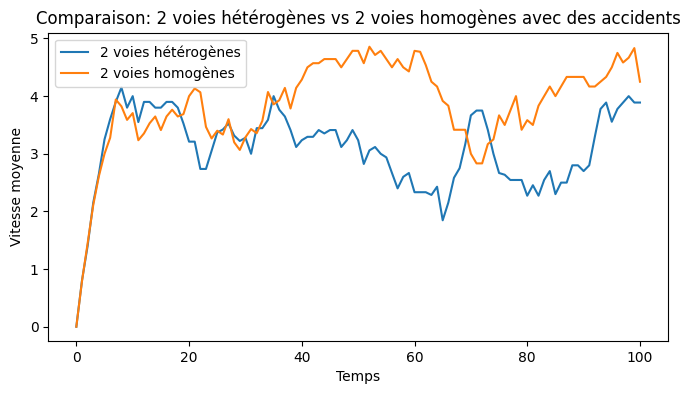

In [ ]:
#maintenant on compare #maintenant on compare 2 voie homogene avec 2 voie heterogene mais avec des accidents

import random
random.seed(0)
taille = 100
nbr_voie = 2
nbr_voiture = 20
p_ex = 0.3
T_sim = 100

vmaxhetero = {i: random.randint(4, 6) for i in range(1, nbr_voiture + 1)}

#  2 voie hétérogène
route2, vitesse2 = config_equidistance_plusieurs_voies(taille, nbr_voie, nbr_voiture)
modele2vhetero = ModelePlusieursVoies(vmaxhetero, p_ex, 0.03, 10)
traj_route2, traj_vitesse2 = modele2vhetero.trajectoire(route2.copy(), vitesse2.copy(), T_sim)
vmoy2hetero = [calculer_vmoy(v) for v in traj_vitesse2]

#  2 voie homogène
route2homo, vitesse2homo = config_equidistance_plusieurs_voies(taille, nbr_voie, nbr_voiture)
modele2vhomo = ModelePlusieursVoies({i: 5 for i in range(1, nbr_voiture + 1)}, p_ex, 0.03, 10)
traj_route2homo, traj_vitesse2homo = modele2vhomo.trajectoire(route2homo.copy(), vitesse2homo.copy(), T_sim)
vmoy2homo = [calculer_vmoy(v) for v in traj_vitesse2homo]

# Comparaisons et affichage
plt.figure(figsize=(8, 4))
plt.plot(vmoy2hetero, label='2 voies hétérogènes')
plt.plot(vmoy2homo, label='2 voies homogènes')
plt.xlabel('Temps')
plt.ylabel('Vitesse moyenne')
plt.legend()
plt.title('Comparaison: 2 voies hétérogènes vs 2 voies homogènes avec des accidents')


